In [5]:
# Molecular Dynamics method
# molecular diffusion problem: 2-dim

using Plots
using Random
using Statistics

In [12]:
mutable struct Molecular_Dynamics
    # scale
    L::Float64          # size
    time::Float64
    iter::Int

    # physical quantities of molecules
    x           # position: -L/2 < x < L/2
    y           # position: -L/2 < y < L/2
    x_old
    y_old
    v_x         # velocity of molecules
    v_y
    force_x
    force_y

    # thermodynamical parameters
    T::Float64              # temperature
    N::Int                  # total number of molecules
    N_A::Int                # number of A molecules
    N_B::Int                # number of B molecules
    density::Float64        # number density of molecules

    mass_ratio::Float64     # M_b / M_a

    # hyper parameters
    dt::Float64
    cutoff_radius::Float64  # cutoff radius of forces

    # subroutines
    _force_update
    _plot_subroutine

    # graph data
    plt

    function _init_position_old(N, L)
        x = []
        y = []
        i = 1
        while i <= N
            accept_flag = true
            (x_candidate, y_candidate) = L * (rand(Float64, 2) .- 0.5)

            # reject the cases that moleculars overlap each other
            for j = 1 : i - 1
                δx = x_candidate - x[j]
                δy = y_candidate - y[j]
                δx -= L * round(δx / L)       # cyclic boundary condition
                δy -= L * round(δy / L)
                if (δx ^ 2 + δy ^ 2) < 1.0
                    accept_flag = false
                    break
                end
            end

            if accept_flag
                i += 1
                push!(x, x_candidate)
                push!(y, y_candidate)
            end
        end

        return x, y
    end

    function _init_velocity(N_A, N, T, mass_ratio)
        # set v_x and v_y according to Maxwell-Boltzmann distribution via Box-Muller algorithm
        v_x = []
        v_y = []
        for _ = 1 : N_A
            box_muller_1 = sqrt(2.0 * T * (-log(rand(Float64))))
            box_muller_2 = 2.0 * π * rand(Float64)
            push!(v_x, box_muller_1 * cos(box_muller_2))
            push!(v_y, box_muller_1 * sin(box_muller_2))
        end
        for _ = N_A + 1 : N
            box_muller_1 = sqrt(2.0 * T * (-log(rand(Float64))) / mass_ratio)
            box_muller_2 = 2.0 * π * rand(Float64)
            push!(v_x, box_muller_1 * cos(box_muller_2))
            push!(v_y, box_muller_1 * sin(box_muller_2))
        end

        # correct total momentum to 0
        momentum_A_x = mean(v_x[1 : N_A])
        momentum_A_y = mean(v_y[1 : N_A])
        momentum_B_x = mean(v_x[N_A + 1 : N])
        momentum_B_y = mean(v_y[N_A + 1 : N])
        for i = 1 : N_A
            v_x[i] -= momentum_A_x
            v_y[i] -= momentum_A_y
        end
        for i = N_A + 1 : N
            v_x[i] -= momentum_B_x
            v_y[i] -= momentum_B_y
        end

        return v_x, v_y
    end

    function _force_update(N, x_old, y_old, L, cutoff_radius; is_cyclic_boundary_condition)
        force_x = zeros(N)
        force_y = zeros(N)
        for i = 1 : N-1
            x_temp = x_old[i]
            y_temp = y_old[i]
            force_x_temp = force_x[i]
            force_y_temp = force_y[i]
            for j = i+1 : N
                distance_x = x_temp - x_old[j]
                distance_y = y_temp - y_old[j]
                if is_cyclic_boundary_condition
                    distance_x -= round(distance_x / L) * L
                    distance_y -= round(distance_y / L) * L
                end

                # cutoff
                distance_ij_squared = distance_x ^ 2 + distance_y ^ 2
                if distance_ij_squared > (cutoff_radius ^ 2)
                    continue
                end

                # Lennard-Jones potential
                coef_6 = distance_ij_squared ^ (-3)
                coef_12 = coef_6 ^ 2
                scale = 24.0 * (2.0 * coef_12 - coef_6) / distance_ij_squared
                force_x_ij = scale * distance_x
                force_y_ij = scale * distance_y
                force_x_temp += force_x_ij
                force_y_temp += force_y_ij
                force_x[j] -= force_x_ij
                force_y[j] -= force_y_ij
            end
            force_x[i] = force_x_temp
            force_y[i] = force_y_temp
        end

        return force_x, force_y
    end

    function _init_position(N_A, N, x_old, y_old, v_x, v_y, force_x, force_y, dt, mass_ratio)
        x = []
        y = []
        for i = 1 : N_A
            push!(x, (x_old[i] + dt * v_x[i] + 0.5 * dt ^ 2 * force_x[i]))
            push!(y, (y_old[i] + dt * v_y[i] + 0.5 * dt ^ 2 * force_y[i]))
        end
        for i = N_A + 1 : N
            push!(x, (x_old[i] + dt * v_x[i] + 0.5 * dt ^ 2 * force_x[i] / mass_ratio))
            push!(y, (y_old[i] + dt * v_y[i] + 0.5 * dt ^ 2 * force_y[i] / mass_ratio))
        end

        return x, y
    end

    function _plot_subroutine(x, y, N_A, N, title)
        plt_temp = scatter(x[1 : N_A], y[1 : N_A], title=title, label="molecular A", size=(1000, 800))
        scatter!(plt_temp, x[N_A + 1 : N], y[N_A + 1 : N], label="molecular B")

        return plt_temp
    end

    function Molecular_Dynamics(T, mass_ratio, N_A, N_B, density; dt=0.001, cutoff_radius=3.0)
        N = N_A + N_B
        L = sqrt(N / density)
        iter = 0
        time = 0.0

        x_old, y_old = _init_position_old(N, L)
        v_x, v_y = _init_velocity(N_A, N, T, mass_ratio)
        force_x, force_y = _force_update(N, x_old, y_old, L, cutoff_radius, is_cyclic_boundary_condition=true)
        x, y = _init_position(N_A, N, x_old, y_old, v_x, v_y, force_x, force_y, dt, mass_ratio)
        plt = [_plot_subroutine(x, y, N_A, N, "initial state")]

        new(L, time, iter, x, y, x_old, y_old, v_x, v_y, force_x, force_y, T, N, N_A, N_B, density, mass_ratio, dt, cutoff_radius, _force_update, _plot_subroutine, plt)
    end
end

function show_parameters(md)
    println("thermodynamical parameters:")
    println("temperature: $(md.T), density: $(md.density)")
    println("# of molecular A: $(md.N_A), # of molecular B: $(md.N_B), total: $(md.N)")
    println("mass ratio: MB / MA: $(md.mass_ratio)")
    println("\nhyper parameters")
    println("dt: $(md.dt), cutoff radius: $(md.cutoff_radius)\n")
end

function solve!(md, iter_max; plot_step=2000)
    show_parameters(md)

    while md.iter <= iter_max
        md.iter += 1
        md.time += md.dt
        force_update!(md)
        position_update!(md)
        plot_position!(md, iter_max, plot_step)
    end

    plot(md.plt...)
end

function force_update!(md)
    md.force_x, md.force_y = md._force_update(md.N, md.x, md.y, md.L, md.cutoff_radius, is_cyclic_boundary_condition=false)
end

function position_update!(md)
    for i = 1 : md.N_A
        temp_x = 2.0 * md.x[i] - md.x_old[i] + md.force_x[i] * md.dt ^ 2
        temp_y = 2.0 * md.y[i] - md.y_old[i] + md.force_y[i] * md.dt ^ 2
        md.x_old[i] = md.x[i]
        md.y_old[i] = md.y[i]
        md.x[i] = temp_x
        md.y[i] = temp_y
    end
    for i = md.N_A + 1 : md.N
        temp_x = 2.0 * md.x[i] - md.x_old[i] + md.force_x[i] * md.dt ^ 2 / md.mass_ratio
        temp_y = 2.0 * md.y[i] - md.y_old[i] + md.force_y[i] * md.dt ^ 2 / md.mass_ratio
        md.x_old[i] = md.x[i]
        md.y_old[i] = md.y[i]
        md.x[i] = temp_x
        md.y[i] = temp_y
    end
end

function plot_position!(md, iter_max, step)
    if md.iter == iter_max
        push!(md.plt, md._plot_subroutine(md.x, md.y, md.N_A, md.N, "final result"))
    elseif md.iter % step == 0
        push!(md.plt, md._plot_subroutine(md.x, md.y, md.N_A, md.N, "step = $(md.iter)"))
    end
end

plot_position! (generic function with 1 method)

In [13]:
md = Molecular_Dynamics(5.0, 10.0, 20, 20, 0.1)
show_parameters(md)

thermodynamical parameters:
temperature: 5.0, density: 0.1
# of molecular A: 20, # of molecular B: 20, total: 40
mass ratio: MB / MA: 10.0

hyper parameters
dt: 0.001, cutoff radius: 3.0



thermodynamical parameters:
temperature: 5.0, density: 0.1
# of molecular A: 20, # of molecular B: 20, total: 40
mass ratio: MB / MA: 10.0

hyper parameters
dt: 0.001, cutoff radius: 3.0



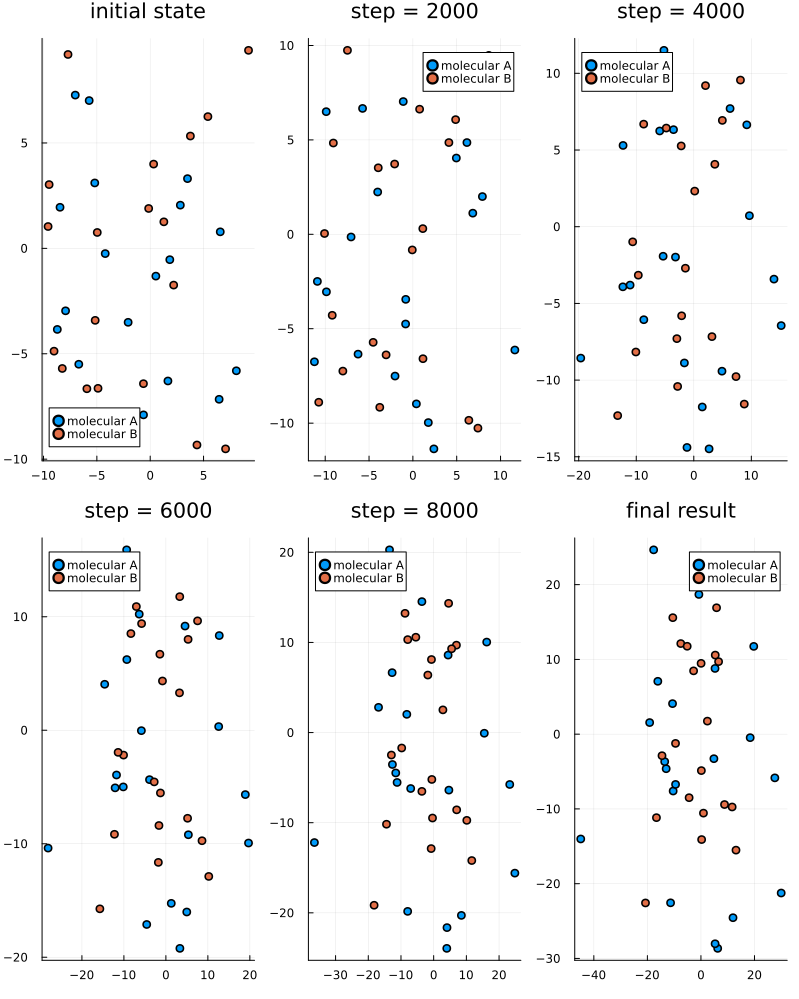

In [11]:
solve!(md, 10000)